# **Parte V: Exploración y Visualización de Datos Avanzada**


En esta quinta parte del proyecto, vamos a expandir nuestro análisis exploratorio de datos (EDA) y visualización utilizando técnicas avanzadas. Aplicaremos todo lo que hemos aprendido hasta ahora, incluyendo cuadrículas, leyendas, anotaciones, flechas, y subplots, para obtener una comprensión más profunda de nuestro conjunto de datos de ventas.

# **1.- Continuar desde la Parte IV**

## **Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.**

In [56]:
# Carga de Archivos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/drive/MyDrive/BootCamp Skillnest-Sonda/data/mobile_sales_data.csv')


print('\n' + '=' * 60)
print('PRIMERAS 5 FILAS')
print('=' * 60)
print(df.head())

print('\n' + '=' * 60)
print('INFORMACIÓN GENERAL')
print('=' * 60)
print(df.info())

print('\n' + '=' * 60)
print('ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 60)
print(df.describe())


PRIMERAS 5 FILAS
        Product      Brand Product Code  \
0  Mobile Phone   Motorola     88EB4558   
1        Laptop       Oppo     416DFEEB   
2  Mobile Phone    Samsung     9F975B08   
3        Laptop       Sony     73D2A7CC   
4        Laptop  Microsoft     CCE0B80D   

                               Product Specification   Price Inward Date  \
0  Site candidate activity company there bit insi...   78570  2023-08-02   
1            Beat put care fight affect address his.   44613  2023-10-03   
2           Energy special low seven place audience.  159826  2025-03-19   
3  Friend record hard contain minute we role sea ...   20911  2024-02-06   
4   Program recently feeling save tree hotel people.   69832  2023-08-10   

  Dispatch Date  Quantity Sold  Customer Name Customer Location   Region  \
0    2023-08-03              6   William Hess      South Kelsey  Central   
1    2023-10-06              1    Larry Smith        North Lisa    South   
2    2025-03-20              5  Leah C

In [57]:
# Nulos
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)

# % de Nulos por columna
print('% de Nulos por columna')
print('-'*30)
print((df.isnull().sum() / len(df)) * 100)

Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                        24983
dtype: int64
% de Nulos por columna
------------------------------
Product                     0.000
Brand                       0.000
Product Code                0.000
Product Specification       0.000
Price                       0.000
Inward Date                 0.000
Dispatch Date               0.000
Quantity Sold               0.000
Customer Name               0.000
Customer Location           0.000
Region                      0.000
Core Specification         49.9

In [58]:
#Total de Valores Nulos del Dataframe
total_valores_nulos = df.isna().sum().sum()
print('Total de valores :')
print(total_valores_nulos)

Total de valores :
49966


In [59]:
#Criterio a Aplicar en nulos
# Como la columna ('Core Specification' )son casi un 50% y son categoricas, se Imputara 'Sin Datos'
df['Core Specification'] = df['Core Specification'].fillna('Sin Datos')

# Esta columna la ocupare como variable numerica
df['SSD'] = df['SSD'].apply(lambda x: 0 if pd.isna(x) or x == 'N/A' else int(str(x).replace('GB', '').replace('TB', '000')))

# Reviso si quedo algun Valor Nulo
print(df.isna().sum())
df.info()

Product                    0
Brand                      0
Product Code               0
Product Specification      0
Price                      0
Inward Date                0
Dispatch Date              0
Quantity Sold              0
Customer Name              0
Customer Location          0
Region                     0
Core Specification         0
Processor Specification    0
RAM                        0
ROM                        0
SSD                        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product                  50000 non-null  object
 1   Brand                    50000 non-null  object
 2   Product Code             50000 non-null  object
 3   Product Specification    50000 non-null  object
 4   Price                    50000 non-null  int64 
 5   Inward Date              50000 non-nul

In [60]:

# Convertir los campos tipo textos a fechas
df['Inward Date'] = pd.to_datetime(df['Inward Date'], errors='coerce')
df['Dispatch Date'] = pd.to_datetime(df['Dispatch Date'], errors='coerce')

# Para el analisis por categioras falta la ventas totales
df['Venta Total'] = df['Price'] * df['Quantity Sold']

# Dias de despacho
df['Dias Despacho'] = (df['Dispatch Date'] - df['Inward Date']).dt.days

# Como  hay pocas varialbes numericas se pueden pasar los tipos de memoria a numero jay que jugar pasar todo a un solo
# Formato en GB t Tb y quintando la unidad de medida


df['RAM'] = df['RAM'].str.replace('GB', '').astype(int)
df['ROM'] = df['ROM'].str.replace('GB', '').str.replace('TB', '000').astype(int)



print('\n' + '=' * 60)
print('Tipo de datos')
print('=' * 50)
print(df.dtypes)


print('Estadisticas de lso camppos cantidad, precio, vental total, los Dias Despacho y ahora los tipo de memoria')
print(df[['Price', 'Quantity Sold', 'Venta Total','Dias Despacho','RAM','ROM','SSD']].describe())


print('--'*80)
print('Venta por producto')
print(df.groupby('Product')['Venta Total'].sum().sort_values(ascending=False))

print('--'*80)
print('Venta por Marca')
print(df.groupby('Brand')['Venta Total'].sum().sort_values(ascending=False).head(10))

print('--'*80)
print('Venta por Region')
print(df.groupby('Region')['Venta Total'].sum().sort_values(ascending=False))



Tipo de datos
Product                            object
Brand                              object
Product Code                       object
Product Specification              object
Price                               int64
Inward Date                datetime64[ns]
Dispatch Date              datetime64[ns]
Quantity Sold                       int64
Customer Name                      object
Customer Location                  object
Region                             object
Core Specification                 object
Processor Specification            object
RAM                                 int64
ROM                                 int64
SSD                                 int64
Venta Total                         int64
Dias Despacho                       int64
dtype: object
Estadisticas de lso camppos cantidad, precio, vental total, los Dias Despacho y ahora los tipo de memoria
               Price  Quantity Sold   Venta Total  Dias Despacho  \
count   50000.000000    50000.00000  5.00

# **2.- Exploración de Datos Avanzada**

## **Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.**

--------------------------------------------------------------------------------
Matriz de correlacion
--------------------------------------------------------------------------------
                  Price  Quantity Sold       RAM       ROM       SSD  \
Price          1.000000      -0.002220 -0.000378  0.004321  0.003721   
Quantity Sold -0.002220       1.000000 -0.002849  0.001794  0.003437   
RAM           -0.000378      -0.002849  1.000000  0.001588  0.005771   
ROM            0.004321       0.001794  0.001588  1.000000 -0.002242   
SSD            0.003721       0.003437  0.005771 -0.002242  1.000000   
Dias Despacho -0.001634       0.001835  0.004817 -0.005258  0.001240   

               Dias Despacho  
Price              -0.001634  
Quantity Sold       0.001835  
RAM                 0.004817  
ROM                -0.005258  
SSD                 0.001240  
Dias Despacho       1.000000  
--------------------------------------------------------------------------------
Grafico de co

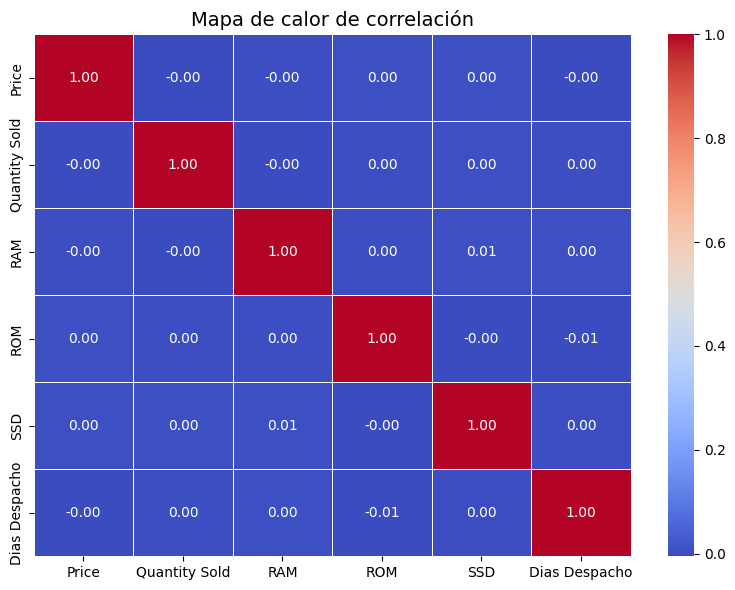

In [61]:
# --------------------------------------------------
# 3. CORRELACIÓN Y MAPA DE CALOR
# Matriz de correlacion

print('--'*40)
print('Matriz de correlacion')
print('--'*40)
numeric_cols = ['Price', 'Quantity Sold', 'RAM', 'ROM','SSD','Dias Despacho']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

print('--'*40)
print('Grafico de correlacion')
print('--'*40)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de calor de correlación', fontsize=14)

plt.tight_layout()
plt.show()

La matriz de correlacion demuestra para este caso que ninguna variable es relacion lineal entre si

## **Crea subplots para comparar diferentes variables clave.**

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

#----------------------------------------
# Ventas por region
#----------------------------------------

ventas_region = df.groupby('Region')['Venta Total'].sum().sort_values(ascending=True)

colores = ['red', 'coral', 'blue', 'green','cyan']
barras = axes[0, 0].barh(ventas_region.index, ventas_region.values, color=colores,
                          edgecolor='white', linewidth=0.8, height=0.6)

# Anotar valores al lado de cada barra
for barra, valor in zip(barras, ventas_region.values):
    axes[0, 0].text(valor + valor * 0.02, barra.get_y() + barra.get_height() / 2,
                    f'${valor:,.0f}', va='center', fontsize=11, fontweight='bold')

axes[0, 0].set_title('Ventas por Región', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Venta Total ', fontsize=11)
axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0, 0].set_axisbelow(True)

#----------------------------------------
# Top 10 Productos por Venta
#----------------------------------------
top10_marcas = df.groupby('Brand')['Venta Total'].sum().sort_values(ascending=True).tail(10)

barras_marcas = axes[0, 1].barh(top10_marcas.index, top10_marcas.values, color='steelblue',
                                 edgecolor='white', linewidth=0.8, height=0.6)

# Anotar valores al lado de cada barra
for barra, valor in zip(barras_marcas, top10_marcas.values):
    axes[0, 1].text(valor + valor * 0.02, barra.get_y() + barra.get_height() / 2,
                    f'${valor:,.0f}', va='center', fontsize=11, fontweight='bold')

axes[0, 1].set_title('Venta Top 10 Marcas', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Venta Total', fontsize=11)
axes[0, 1].grid(axis='x', alpha=0.3, linestyle='--')
axes[0, 1].set_axisbelow(True)


#----------------------------------------
# Histograma de precios
#----------------------------------------

axes[1, 0].hist( df['Price'], bins=30, edgecolor='blue', alpha=0.4)
# saco la media
media = df['Price'].mean()

# saco la mediana
mediana = df['Price'].median()

axes[1, 0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media: ${media:,.0f}')
axes[1, 0].axvline(mediana, color='red', linestyle='-', linewidth=2, label=f'Mediana: ${mediana:,.0f}')

# Flecha con la anotacion
axes[1, 0].annotate(f'Media: ${media:,.0f}', xy=(media, axes[1, 0].get_ylim()[1] * 0.8),
    xytext=(media + (df['Price'].std()), axes[1, 0].get_ylim()[1] * 0.95),
    fontsize=10, fontweight='bold',  arrowprops=dict(arrowstyle='->', color='blue', lw=1.5) )

axes[1, 0].set_title('Distribución de Precios', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Precio ($)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.4)

#----------------------------------------
# Ventas mensuales por año
#----------------------------------------
# saco el mes para el calculo y orden
df['Mes'] = df['Dispatch Date'].dt.to_period('M').astype(str)

ventas_mensuales = df.groupby('Mes')['Venta Total'].sum().reset_index()

axes[1, 1].plot(ventas_mensuales['Mes'], ventas_mensuales['Venta Total'],
                color='orange', marker='o', linewidth=2,
                markersize=6, markerfacecolor='white',
                markeredgewidth=2, label='Venta mensual')

# mes con mayor venta
idx_max = ventas_mensuales['Venta Total'].idxmax()
mes_max = ventas_mensuales.loc[idx_max, 'Mes']

# Valor de ese periodo
valor_max = ventas_mensuales.loc[idx_max, 'Venta Total']

# Flecha con la anotacion
axes[1, 1].annotate(
    f'Mayor venta\n{mes_max}\n${valor_max:,.0f}',
    xy=(idx_max, valor_max),    xytext=(idx_max - 2, valor_max * 1.15),
    fontsize=10,    fontweight='bold',    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)

)

axes[1, 1].set_title('Ventas Mensuales por Año', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Venta Total')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1, 1].set_axisbelow(True)
axes[1, 1].legend(fontsize=10)

#---------------------------------------

# Agrupar por Marca y Producto, sumar ventas
ventas_marca = df.groupby(['Brand', 'Product'])['Venta Total'].sum().unstack(fill_value=0)
ventas_marca['Total'] = ventas_marca.sum(axis=1)
ventas_marca = ventas_marca.sort_values('Total', ascending=False)

# Quitar la columna Total para el gráfico (solo Laptop y Mobile Phone)
ventas_marca[['Laptop', 'Mobile Phone']].plot(
    kind='bar',
    ax=ax,
    color=['coral', 'darkgray'],
    edgecolor='black',
    linewidth=0.8,
    width=0.7
)


plt.tight_layout()
plt.show()



La Zona West tiene mas ventas pero no se ve que área es la que mas venta genera Notebooks o Celulares.

Google es la marca que tiene mas ventas (en el grafico de mas abajo) se ve que en generar las marcas tienen una venta homogénea entre Notebooks y celulares.

La distribución de precios la mediana y la media están casi iguales.

El mes 8 del año 2023 fue el peak de ventas y en 05-2025 hay una caída de las ventas, puede ser que no hubo mas recolección de datos o hubo un cierre de la tienda de análisis.


In [ ]:
# no pude agregarlo al subplot asi que lo imprimo aqui para ver la partipacion de la marca por producto  Notebook o cleular

fig, ax = plt.subplots(figsize=(12, 4))

# Reviso las venta de la marca por producto  Notebook o cleular
ventas_marca = df.groupby(['Brand', 'Product'])['Venta Total'].sum().unstack(fill_value=0)
ventas_marca['Total'] = ventas_marca.sum(axis=1)
ventas_marca = ventas_marca.sort_values('Total', ascending=False)


ventas_marca[['Laptop', 'Mobile Phone']].plot( kind='bar', ax=ax, color=['coral', 'darkgray'], edgecolor='black',linewidth=0.8, width=0.7)

ax.set_title('Ventas por Marca / Notebook vs Celular', fontsize=14, fontweight='bold')
ax.set_xlabel('Marca')
ax.set_ylabel('Venta Total')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Producto', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


Hay una venta muy similar por tipo de producto de las marcas
